# BioSeqFeat Tutorial: Comparing Protein Similarity with BLOSUM Featurizers

This notebook walks through using `Pipeline` and the BLOSUM featurizers to measure
sequence-level similarity between proteins.

We use four well-known human proteins that span a range of evolutionary distances:

| Protein | Function | Expected similarity to HBA |
|---|---|---|
| **HBA** – Hemoglobin α | O₂ transport (tetramer) | — (reference) |
| **HBB** – Hemoglobin β | O₂ transport (tetramer) | High (same fold, ~44% identity) |
| **MYO** – Myoglobin | O₂ storage (muscle) | Moderate (globin family, ~25% identity) |
| **LYS** – Lysozyme | Antimicrobial enzyme | Low (unrelated fold) |

**Key concepts covered:**
- `BlosumAvg` — mean BLOSUM62 embedding, captures overall amino acid composition
- `BlosumCompress` — position-aware compression, preserves sequence order information
- `Pipeline` — weighted combination; cosine similarity on the output equals weighted cosine over feature blocks

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from bioseqfeat import BlosumAvg, BlosumCompress, Pipeline

## 2. Protein sequences

Canonical mature sequences (UniProt: P69905, P68871, P02144, P61626).

In [40]:
proteins = {
    "HBA\n(Hemoglobin α)": (
        "VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGK"
        "KVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP"
        "AVHASLDKFLASVSTVLTSKYR"
    ),
    "HBB\n(Hemoglobin β)": (
        "VHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPK"
        "VKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHF"
        "GKEFTPPVQAAYQKVVAGVANALAHKYH"
    ),
    "MYO\n(Myoglobin)": (
        "GLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASE"
        "DLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKH"
        "PGDFGADAQGAMNKALELFRKDMASNYKELGFQG"
    ),
    "LYS\n(Lysozyme)": (
        "KVFERCELARTLKRLGMDGYRGISLANWMCLAKWESGYNTRATNYNAGDRSTDYGIFQIN"
        "SRYWCNDGKTPGAVNACHLSCSALLQDNIADAVACAKRVVRDPQGIRAWVAWRNRCQNRD"
        "VRQYVQGCGV"
    ),
}

names = list(proteins.keys())
seqs  = list(proteins.values())

for name, seq in proteins.items():
    label = name.replace('\n', ' ')
    print(f"{label:<25} {len(seq):>3} residues")

HBA (Hemoglobin α)        141 residues
HBB (Hemoglobin β)        146 residues
MYO (Myoglobin)           153 residues
LYS (Lysozyme)            130 residues


## 3. Featurizer overview

Each featurizer converts a sequence string into a fixed-length numpy vector.

In [41]:
avg      = BlosumAvg()
compress = BlosumCompress(dim=50, method="dct")

example = seqs[0]
print(f"BlosumAvg output shape      : {avg.extract_one(example).shape}")
print(f"BlosumCompress output shape  : {compress.extract_one(example).shape}")
print()
print(avg)
print(compress)

BlosumAvg output shape      : (20,)
BlosumCompress output shape  : (1000,)

BlosumAvg('blosum_avg')
BlosumCompress('blosum_compress')


## 4. BlosumAvg — composition-based similarity

`BlosumAvg` averages BLOSUM62 row vectors across all residues.
It captures **amino acid composition** but ignores sequence order.

In [42]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def similarity_matrix(featurizer, sequences: list[str]) -> np.ndarray:
    """Compute pairwise cosine similarity for a list of sequences."""
    vecs = featurizer.extract_batch(sequences)  # (N, D)
    # Normalise rows, then dot product gives cosine similarity
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    normed = vecs / norms
    return normed @ normed.T

avg_sim = similarity_matrix(avg, seqs)
print("BlosumAvg cosine similarity matrix:")
print(np.round(avg_sim, 3))

BlosumAvg cosine similarity matrix:
[[1.    0.994 0.972 0.972]
 [0.994 1.    0.981 0.977]
 [0.972 0.981 1.    0.972]
 [0.972 0.977 0.972 1.   ]]


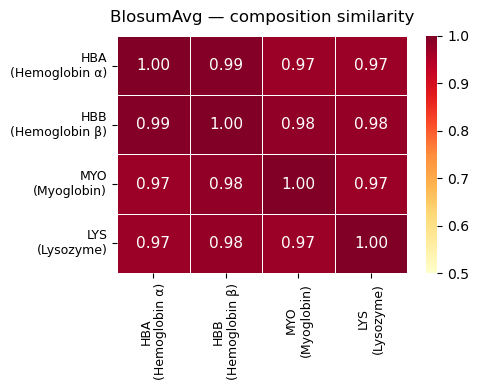

In [43]:
def plot_similarity(sim: np.ndarray, labels: list[str], title: str, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        sim, annot=True, fmt=".2f", vmin=0.5, vmax=1.0,
        cmap="YlOrRd", xticklabels=labels, yticklabels=labels,
        linewidths=0.5, linecolor="white", ax=ax,
        annot_kws={"size": 11},
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.tick_params(labelsize=9)
    return ax

plot_similarity(avg_sim, names, "BlosumAvg — composition similarity")
plt.tight_layout()
plt.show()

## 5. BlosumCompress — position-aware similarity

`BlosumCompress` compresses the full per-residue embedding matrix into *dim* positional
bins using DCT. This preserves **where** in the sequence each amino acid pattern appears.

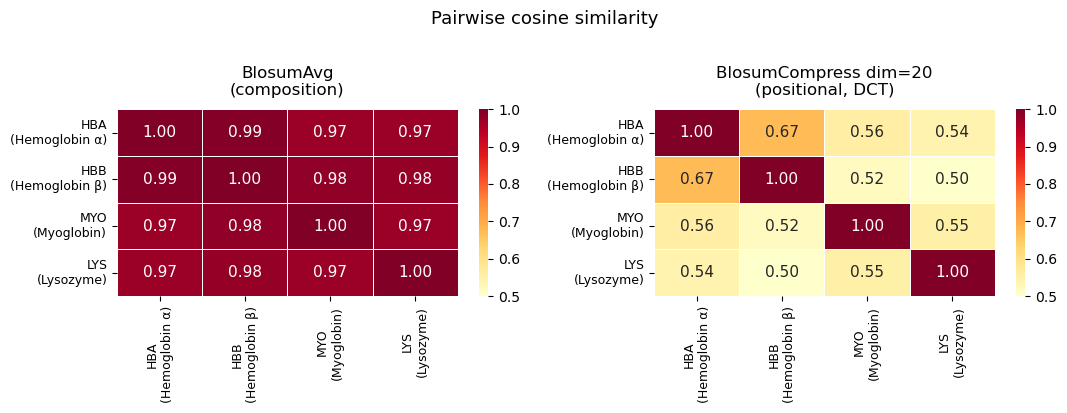

In [44]:
compress_sim = similarity_matrix(compress, seqs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_similarity(avg_sim,      names, "BlosumAvg\n(composition)",       axes[0])
plot_similarity(compress_sim, names, "BlosumCompress dim=20\n(positional, DCT)", axes[1])
plt.suptitle("Pairwise cosine similarity", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Pipeline — weighted combination

A `Pipeline` scales each featurizer's block by `sqrt(weight)` before concatenation.
This means **standard cosine similarity on the concatenated vector equals weighted
cosine similarity over individual blocks** — no custom distance function needed.

Here we weight positional information 3× higher than composition.

In [37]:
pipe = Pipeline(
    featurizers=[avg, compress],
    weights=[1.0, 3.0],   # positional features weighted 3x more than composition
)
print(pipe)

vec = pipe.extract_one(seqs[0])
print(f"\nOutput vector length: {len(vec)}  (= 20 + 20×20 = {20 + 20*20})")

Pipeline([blosum_avg=1, blosum_compress=3])

Output vector length: 420  (= 20 + 20×20 = 420)


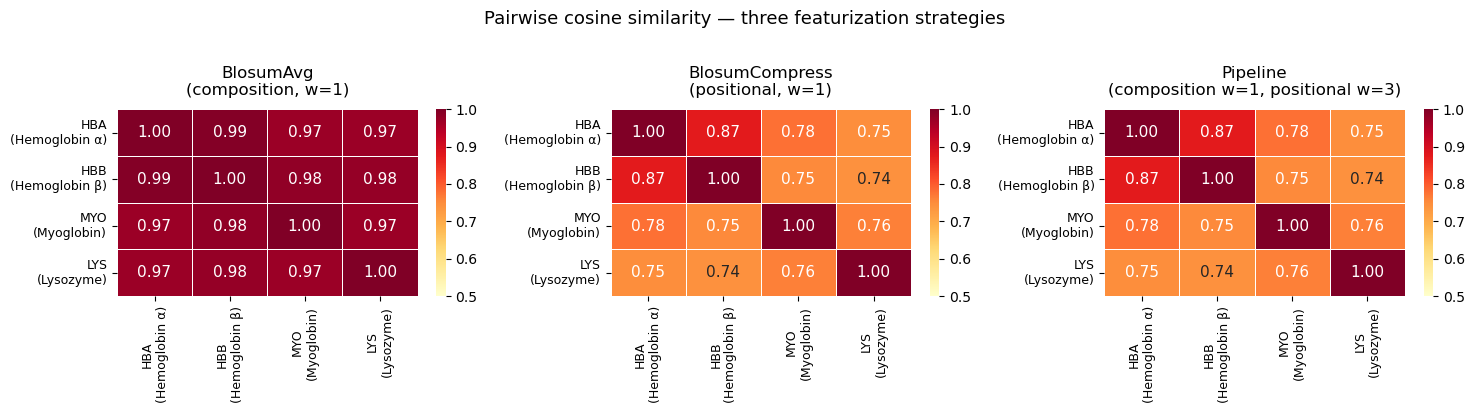

In [38]:
pipe_sim = similarity_matrix(pipe, seqs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_similarity(avg_sim,      names, "BlosumAvg\n(composition, w=1)",        axes[0])
plot_similarity(compress_sim, names, "BlosumCompress\n(positional, w=1)",     axes[1])
plot_similarity(pipe_sim,     names, "Pipeline\n(composition w=1, positional w=3)", axes[2])
plt.suptitle("Pairwise cosine similarity — three featurization strategies", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Effect of weighting

Sweeping the weight ratio lets us interpolate between pure composition and pure
positional similarity. We track the HBA–HBB pair (close) vs the HBA–LYS pair (distant).

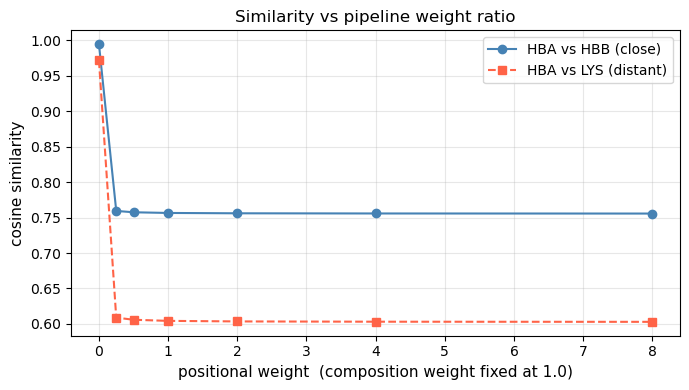

In [32]:
weight_ratios = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]  # compress_weight / avg_weight

hba_hbb_sims = []
hba_lys_sims = []

for ratio in weight_ratios:
    p = Pipeline([avg, compress], weights=[1.0, ratio])
    sim = similarity_matrix(p, seqs)
    hba_hbb_sims.append(sim[0, 1])   # HBA vs HBB
    hba_lys_sims.append(sim[0, 3])   # HBA vs LYS

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weight_ratios, hba_hbb_sims, "o-", label="HBA vs HBB (close)",    color="steelblue")
ax.plot(weight_ratios, hba_lys_sims, "s--", label="HBA vs LYS (distant)", color="tomato")
ax.set_xlabel("positional weight  (composition weight fixed at 1.0)", fontsize=11)
ax.set_ylabel("cosine similarity", fontsize=11)
ax.set_title("Similarity vs pipeline weight ratio", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

| Featurizer | Captures | Typical use |
|---|---|---|
| `BlosumAvg` | Amino acid composition | Fast, order-invariant baseline |
| `BlosumCompress` | Positional amino acid patterns | When sequence order matters |
| `Pipeline([avg, compress], weights=[w1, w2])` | Weighted blend of both | Tunable for downstream task |

**Key takeaway:** The globin proteins (HBA, HBB, MYO) consistently score higher against
each other than against Lysozyme across all featurization strategies, reflecting their
shared evolutionary origin.